# Cell 1 — Imports

In [1]:
!pip -q install ultralytics ensemble-boxes pydicom opencv-python-headless pyyaml torchvision

import os
import json
import math
import random
import shutil
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score
from ultralytics import YOLO

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True

print("Imports done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports done


# Cell 2 — Paths and model loading

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Current known paths from your checked input structure
PREP_ROOT = "/kaggle/input/datasets/naresh26032005/vinbigdata-prep"
COMP_ROOT = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection"
RESNET_ROOT = "/kaggle/input/datasets/nareshr22mis0015/resnet50-advanced"
YOLO640_ROOT = "/kaggle/input/datasets/nareshr22mis0015/yolo640-fixed"
YOLO1024_ROOT = "/kaggle/input/datasets/nareshr22mis0015/yolo1024-stage2-bundle"

TRAIN_CSV = os.path.join(COMP_ROOT, "train.csv")
SAMPLE_SUB = os.path.join(COMP_ROOT, "sample_submission.csv")
TEST_DIR = os.path.join(COMP_ROOT, "test")

assert os.path.exists(PREP_ROOT), "PREP_ROOT missing"
assert os.path.exists(TRAIN_CSV), "train.csv missing"
assert os.path.exists(TEST_DIR), "test folder missing"

print("PREP_ROOT:", PREP_ROOT)
print("COMP_ROOT:", COMP_ROOT)
print("RESNET_ROOT:", RESNET_ROOT)
print("YOLO640_ROOT:", YOLO640_ROOT)
print("YOLO1024_ROOT:", YOLO1024_ROOT)

# Files
CACHE_CSV = os.path.join(PREP_ROOT, "cache_df.csv")
TRAIN_SPLIT = os.path.join(PREP_ROOT, "splits", "train_split.csv")
VAL_SPLIT = os.path.join(PREP_ROOT, "splits", "val_split.csv")

RESNET_BINARY_PATH = os.path.join(RESNET_ROOT, "resnet50_binary_best.pth")
RESNET_MULTI_PATH = os.path.join(RESNET_ROOT, "resnet50_multilabel_best.pth")
RESNET_THRESH_PATH = os.path.join(RESNET_ROOT, "best_class_thresholds_tta.npy")
BIN_THRESH_TXT = os.path.join(RESNET_ROOT, "best_binary_threshold.txt")

YOLO640_PATH = os.path.join(YOLO640_ROOT, "best_yolov8m_640.pt")
YOLO1024_PATH = os.path.join(YOLO1024_ROOT, "yolov8m_1024_final.pt")

required = [
    CACHE_CSV, TRAIN_SPLIT, VAL_SPLIT,
    RESNET_BINARY_PATH, RESNET_MULTI_PATH, RESNET_THRESH_PATH, BIN_THRESH_TXT,
    YOLO640_PATH, YOLO1024_PATH,
    TRAIN_CSV, SAMPLE_SUB, TEST_DIR
]

for p in required:
    assert os.path.exists(p), f"Missing required file/folder: {p}"

print("All required files found")

Device: cuda
PREP_ROOT: /kaggle/input/datasets/naresh26032005/vinbigdata-prep
COMP_ROOT: /kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection
RESNET_ROOT: /kaggle/input/datasets/nareshr22mis0015/resnet50-advanced
YOLO640_ROOT: /kaggle/input/datasets/nareshr22mis0015/yolo640-fixed
YOLO1024_ROOT: /kaggle/input/datasets/nareshr22mis0015/yolo1024-stage2-bundle
All required files found


# Cell 3 — Labels and maps

In [3]:
CLASS_NAMES = [
    "Aortic enlargement",
    "Atelectasis",
    "Calcification",
    "Cardiomegaly",
    "Consolidation",
    "ILD",
    "Infiltration",
    "Lung Opacity",
    "Nodule/Mass",
    "Other lesion",
    "Pleural effusion",
    "Pleural thickening",
    "Pneumothorax",
    "Pulmonary fibrosis",
    "No finding",
]
NUM_CLASSES = len(CLASS_NAMES)
NO_FINDING_ID = 14
DETECTION_CLASS_IDS = list(range(14))
RARE_CLASS_IDS = {2, 8, 9, 11, 12, 13}
FOCUS_CLASS_IDS = {1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13}

def parse_classes(s):
    if pd.isna(s) or str(s).strip() == "":
        return []
    return [int(x) for x in str(s).split() if str(x).strip().isdigit()]

cache_df = pd.read_csv(CACHE_CSV)
train_split = pd.read_csv(TRAIN_SPLIT)
val_split = pd.read_csv(VAL_SPLIT)
train_df = pd.read_csv(TRAIN_CSV)

# image-level labels
image_label_map = {}
for img_id, g in train_df.groupby("image_id"):
    cls_ids = set(g["class_id"].astype(int).tolist())
    image_label_map[img_id] = {
        "has_abnormal": any(c != NO_FINDING_ID for c in cls_ids),
        "has_no_finding": (NO_FINDING_ID in cls_ids) and len(cls_ids) == 1,
        "classes": sorted(cls_ids),
    }

# GT boxes
ann_per_image = defaultdict(list)
for _, row in train_df.iterrows():
    img_id = row["image_id"]
    cls_id = int(row["class_id"])
    if cls_id == NO_FINDING_ID:
        continue
    if pd.isna(row["x_min"]) or pd.isna(row["y_min"]) or pd.isna(row["x_max"]) or pd.isna(row["y_max"]):
        continue
    ann_per_image[img_id].append({
        "class_id": cls_id,
        "bbox": [float(row["x_min"]), float(row["y_min"]), float(row["x_max"]), float(row["y_max"])],
    })

def iou_xyxy(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter = inter_w * inter_h
    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    union = area1 + area2 - inter + 1e-9
    return inter / union

def merge_boxes_same_class(boxes, iou_thr=0.5, min_area=8.0):
    grouped = defaultdict(list)
    for b in boxes:
        grouped[int(b["class_id"])].append(b)

    merged = []
    for cls_id, items in grouped.items():
        used = [False] * len(items)
        for i in range(len(items)):
            if used[i]:
                continue
            b0 = items[i]["bbox"]
            area0 = max(0, b0[2] - b0[0]) * max(0, b0[3] - b0[1])
            if area0 < min_area:
                used[i] = True
                continue
            cluster = [items[i]]
            used[i] = True
            for j in range(i + 1, len(items)):
                if used[j]:
                    continue
                if iou_xyxy(items[i]["bbox"], items[j]["bbox"]) >= iou_thr:
                    cluster.append(items[j])
                    used[j] = True
            arr = np.array([c["bbox"] for c in cluster], dtype=np.float32)
            merged.append({"class_id": cls_id, "bbox": arr.mean(axis=0).tolist()})
    return merged

fused_ann_per_image = {img_id: merge_boxes_same_class(boxes, iou_thr=0.5) for img_id, boxes in ann_per_image.items()}
print("GT ready:", len(fused_ann_per_image))

GT ready: 4394


# Cell 4 — Image preprocessing# 

In [4]:
def ensure_uint8(img):
    img = img.astype(np.float32)
    img = img - img.min()
    mx = img.max()
    if mx > 0:
        img = img / mx
    return (img * 255.0).clip(0, 255).astype(np.uint8)

def read_dicom(path):
    ds = pydicom.dcmread(path)
    img = ds.pixel_array
    try:
        img = apply_voi_lut(img, ds)
    except Exception:
        pass
    img = img.astype(np.float32)
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = np.max(img) - img
    if np.ptp(img) > 0:
        img = (img - img.min()) / (img.max() - img.min())
    else:
        img = np.zeros_like(img, dtype=np.float32)
    return (img * 255.0).clip(0, 255).astype(np.uint8)

def read_image_any(path):
    ext = Path(path).suffix.lower()
    if ext in [".dcm", ".dicom"]:
        return read_dicom(path)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Unable to read image: {path}")
    return img

def chest_roi_crop(img, pad=0.06):
    thr = max(5, int(np.percentile(img, 5)))
    mask = (img > thr).astype(np.uint8) * 255
    coords = cv2.findNonZero(mask)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    H, W = img.shape[:2]
    x1 = max(0, int(x - pad * w))
    y1 = max(0, int(y - pad * h))
    x2 = min(W, int(x + w + pad * w))
    y2 = min(H, int(y + h + pad * h))
    crop = img[y1:y2, x1:x2]
    return crop if crop.size > 0 else img

def lung_window(img):
    lo = np.percentile(img, 2)
    hi = np.percentile(img, 70)
    out = np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)
    return (out * 255).astype(np.uint8)

def mediastinal_window(img):
    lo = np.percentile(img, 10)
    hi = np.percentile(img, 90)
    out = np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)
    return (out * 255).astype(np.uint8)

def detail_window(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img)

def cxr_to_3window(img_gray):
    img_gray = ensure_uint8(img_gray)
    return np.stack(
        [lung_window(img_gray), mediastinal_window(img_gray), detail_window(img_gray)],
        axis=-1
    )

def preprocess_tta_views(path, img_size=224, use_roi=True):
    img = read_image_any(path)
    img = ensure_uint8(img)
    if use_roi:
        img = chest_roi_crop(img)
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
    return [img, cv2.flip(img, 1)]

def get_cache_path(image_id):
    row = cache_df[cache_df["image_id"] == image_id]
    if len(row) == 0:
        return None
    return os.path.join(PREP_ROOT, row.iloc[0]["cache_path_rel"])

# Cell 5 — Models

In [5]:
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=1, pretrained=False, dropout=0.25):
        super().__init__()
        try:
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            backbone = models.resnet50(weights=weights)
        except Exception:
            backbone = models.resnet50(pretrained=pretrained)

        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats)

class ResNet50Binary(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        self.model = ResNet50Classifier(num_classes=1, pretrained=pretrained)

    def forward(self, x):
        return self.model(x).squeeze(1)

class ResNet50MultiLabel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=False):
        super().__init__()
        self.model = ResNet50Classifier(num_classes=num_classes, pretrained=pretrained)

    def forward(self, x):
        return self.model(x)

# Cell 6 — Load models and thresholds

In [6]:
binary_model = ResNet50Binary(pretrained=False).to(device)
binary_model.load_state_dict(torch.load(RESNET_BINARY_PATH, map_location=device))
binary_model.eval()

multi_model = ResNet50MultiLabel(pretrained=False).to(device)
multi_model.load_state_dict(torch.load(RESNET_MULTI_PATH, map_location=device))
multi_model.eval()

best_class_thresholds = np.load(RESNET_THRESH_PATH)
if len(best_class_thresholds) != NUM_CLASSES:
    best_class_thresholds = np.full(NUM_CLASSES, 0.5, dtype=np.float32)

if os.path.exists(BIN_THRESH_TXT):
    with open(BIN_THRESH_TXT, "r") as f:
        best_binary_threshold = float(f.read().strip())
else:
    best_binary_threshold = 0.5

print("Models loaded")
print("Binary threshold:", best_binary_threshold)

Models loaded
Binary threshold: 0.7000000000000001


# Cell 7 — YOLO models, WBF, and TTA streams

In [7]:
id="nb5_07"
yolo640 = YOLO(YOLO640_PATH)
yolo1024 = YOLO(YOLO1024_PATH)

try:
    from ensemble_boxes import weighted_boxes_fusion
    HAS_WBF = True
except Exception:
    HAS_WBF = False

def yolo_predict_single(model, img_bgr, imgsz=640, conf=0.2, iou=0.45):
    result = model.predict(source=img_bgr, imgsz=imgsz, conf=conf, iou=iou, verbose=False)[0]
    dets = []
    if result.boxes is None or len(result.boxes) == 0:
        return dets
    for b in result.boxes:
        x1, y1, x2, y2 = b.xyxy[0].tolist()
        dets.append({
            "bbox": [x1, y1, x2, y2],
            "conf": float(b.conf[0].item()),
            "class_id": int(b.cls[0].item()),
        })
    return dets

def flip_boxes_back(dets, width):
    out = []
    for d in dets:
        x1, y1, x2, y2 = d["bbox"]
        out.append({
            "bbox": [width - x2, y1, width - x1, y2],
            "conf": d["conf"],
            "class_id": d["class_id"],
        })
    return out

def yolo_tta_dets(model, image_path, imgsz=640, conf=0.2, iou=0.45):
    img = read_image_any(image_path)
    img = ensure_uint8(img)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    H, W = img.shape[:2]

    dets_all = []

    # original
    dets_all.extend(yolo_predict_single(model, img_bgr, imgsz=imgsz, conf=conf, iou=iou))

    # horizontal flip
    flip_bgr = cv2.flip(img_bgr, 1)
    flip_dets = yolo_predict_single(model, flip_bgr, imgsz=imgsz, conf=conf, iou=iou)
    dets_all.extend(flip_boxes_back(flip_dets, W))

    return dets_all, (H, W)

def run_wbf(boxes_list, scores_list, labels_list, iou_thr=0.55, skip_box_thr=0.0001, weights=None):
    if HAS_WBF:
        boxes, scores, labels = weighted_boxes_fusion(
            boxes_list,
            scores_list,
            labels_list,
            weights=weights,
            iou_thr=iou_thr,
            skip_box_thr=skip_box_thr,
            conf_type="avg",
        )
        return boxes, scores, labels

    all_boxes, all_scores, all_labels = [], [], []
    for b, s, l in zip(boxes_list, scores_list, labels_list):
        all_boxes.extend(b)
        all_scores.extend(s)
        all_labels.extend(l)
    return all_boxes, all_scores, all_labels

def fuse_two_yolos(image_path, conf640=0.10, conf1024=0.08):
    img = read_image_any(image_path)
    H, W = img.shape[:2]

    dets640, _ = yolo_tta_dets(yolo640, image_path, imgsz=640, conf=conf640, iou=0.45)
    dets1024, _ = yolo_tta_dets(yolo1024, image_path, imgsz=1024, conf=conf1024, iou=0.45)

    boxes_list, scores_list, labels_list = [], [], []

    for dets in [dets640, dets1024]:
        boxes, scores, labels = [], [], []
        for d in dets:
            x1, y1, x2, y2 = d["bbox"]
            boxes.append([x1 / W, y1 / H, x2 / W, y2 / H])
            scores.append(d["conf"])
            labels.append(d["class_id"])
        boxes_list.append(boxes)
        scores_list.append(scores)
        labels_list.append(labels)

    weights = [1.0, 1.15]
    fused_boxes, fused_scores, fused_labels = run_wbf(
        boxes_list,
        scores_list,
        labels_list,
        iou_thr=0.55,
        skip_box_thr=0.0001,
        weights=weights,
    )

    dets = []
    for box, score, label in zip(fused_boxes, fused_scores, fused_labels):
        dets.append({
            "bbox": [box[0] * W, box[1] * H, box[2] * W, box[3] * H],
            "conf": float(score),
            "class_id": int(label),
        })

    return dets, (H, W)

# Cell 8 — ResNet TTA and advanced crop refinement

In [8]:
def tta_predict_binary(image_path):
    views = preprocess_tta_views(image_path, img_size=224, use_roi=True)
    probs = []
    with torch.no_grad():
        for view in views:
            img3 = cxr_to_3window(view)
            x = torch.from_numpy(img3).permute(2, 0, 1).float() / 255.0
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            x = ((x - mean) / std).unsqueeze(0).to(device)
            logit = binary_model(x)
            probs.append(torch.sigmoid(logit).item())
    return float(np.mean(probs))

def tta_predict_multilabel(image_path):
    views = preprocess_tta_views(image_path, img_size=224, use_roi=True)
    probs_list = []
    with torch.no_grad():
        for view in views:
            img3 = cxr_to_3window(view)
            x = torch.from_numpy(img3).permute(2, 0, 1).float() / 255.0
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            x = ((x - mean) / std).unsqueeze(0).to(device)
            logits = multi_model(x)
            probs_list.append(torch.sigmoid(logits).squeeze(0).cpu().numpy())
    return np.mean(probs_list, axis=0)

def expand_bbox(bbox, shape, pad=0.08):
    H, W = shape[:2]
    x1, y1, x2, y2 = bbox
    bw = x2 - x1
    bh = y2 - y1
    x1 = int(max(0, x1 - pad * bw))
    y1 = int(max(0, y1 - pad * bh))
    x2 = int(min(W - 1, x2 + pad * bw))
    y2 = int(min(H - 1, y2 + pad * bh))
    if x2 <= x1:
        x2 = min(W - 1, x1 + 2)
    if y2 <= y1:
        y2 = min(H - 1, y1 + 2)
    return [x1, y1, x2, y2]

def crop_from_bbox(img_gray, bbox, pad=0.08):
    exp = expand_bbox(bbox, img_gray.shape, pad=pad)
    x1, y1, x2, y2 = exp
    crop = img_gray[y1:y2, x1:x2]
    return crop if crop.size > 0 else img_gray

def crop_probs_two_stage(crop_gray):
    """
    Two-pass crop scoring:
    - tight crop
    - slightly expanded crop
    """
    crop_gray = ensure_uint8(crop_gray)
    crop_gray = cv2.resize(crop_gray, (224, 224), interpolation=cv2.INTER_AREA)

    views_1 = [crop_gray, cv2.flip(crop_gray, 1)]
    probs_1 = []
    with torch.no_grad():
        for view in views_1:
            img3 = cxr_to_3window(view)
            x = torch.from_numpy(img3).permute(2, 0, 1).float() / 255.0
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            x = ((x - mean) / std).unsqueeze(0).to(device)
            logits = multi_model(x)
            probs_1.append(torch.sigmoid(logits).squeeze(0).cpu().numpy())

    return np.mean(probs_1, axis=0)

def adaptive_class_thresholds(binary_prob, global_probs):
    """
    Start from trained thresholds, then adapt for recall.
    Lower thresholds for difficult classes, raise them a bit if the image looks normal.
    """
    base = best_class_thresholds.copy()

    # strong rescue for low-sample difficult classes
    rescue_floor = np.array([
        0.22,  # Aortic enlargement
        0.12,  # Atelectasis
        0.10,  # Calcification
        0.22,  # Cardiomegaly
        0.10,  # Consolidation
        0.10,  # ILD
        0.10,  # Infiltration
        0.10,  # Lung Opacity
        0.10,  # Nodule/Mass
        0.10,  # Other lesion
        0.12,  # Pleural effusion
        0.10,  # Pleural thickening
        0.10,  # Pneumothorax
        0.10,  # Pulmonary fibrosis
        0.65,  # No finding
    ], dtype=np.float32)

    thr = 0.55 * base + 0.45 * rescue_floor

    # image-level adjustment
    normal_prob = float(global_probs[NO_FINDING_ID])
    abnormal_prob = float(binary_prob)

    if normal_prob > 0.80 and abnormal_prob < 0.35:
        thr[:14] += 0.04
    elif abnormal_prob > 0.65 or normal_prob < 0.55:
        thr[:14] -= 0.03

    # extra leniency for the hardest classes
    for c in RARE_CLASS_IDS:
        thr[c] -= 0.02

    thr[:14] = np.clip(thr[:14], 0.05, 0.55)
    thr[NO_FINDING_ID] = np.clip(thr[NO_FINDING_ID], 0.50, 0.85)
    return thr

def refine_detection(image_gray, det, binary_prob, global_probs):
    """
    Rescore a detection using:
    - crop ResNet TTA
    - expanded crop ResNet TTA
    - image-level multilabel prior
    - binary gate
    """
    crop1 = crop_from_bbox(image_gray, det["bbox"], pad=0.06)
    crop2 = crop_from_bbox(image_gray, det["bbox"], pad=0.16)

    probs1 = crop_probs_two_stage(crop1)
    probs2 = crop_probs_two_stage(crop2)
    probs = 0.65 * probs1 + 0.35 * probs2

    yolo_cls = int(det["class_id"])
    yolo_conf = float(det["conf"])
    global_top = int(np.argmax(global_probs[:14]))
    adaptive_thr = adaptive_class_thresholds(binary_prob, global_probs)

    # Candidate selection: allow rescue if crop or global supports it
    candidates = [c for c in range(14) if probs[c] >= adaptive_thr[c]]

    if len(candidates) > 0:
        # score candidate by crop + global + agreement with YOLO
        def candidate_score(c):
            score = (
                0.50 * probs[c] +
                0.25 * global_probs[c] +
                0.25 * (1.0 if c == yolo_cls else 0.0)
            )
            if c in RARE_CLASS_IDS:
                score *= 1.08
            if c == global_top:
                score *= 1.04
            return score

        cls_id = max(candidates, key=candidate_score)
        conf = float(candidate_score(cls_id))
    else:
        # Rescue path: trust YOLO if it is not too weak; otherwise use crop top disease
        crop_top = int(np.argmax(probs[:14]))
        crop_top_prob = float(probs[crop_top])

        if probs[yolo_cls] >= max(0.08, adaptive_thr[yolo_cls] * 0.75):
            cls_id = yolo_cls
            conf = float(0.55 * yolo_conf + 0.45 * probs[yolo_cls])
        elif crop_top_prob >= 0.10:
            cls_id = crop_top
            conf = float(0.55 * yolo_conf + 0.45 * crop_top_prob)
        else:
            # no confident disease
            return None

    # Strong background suppression
    normal_prob = float(global_probs[NO_FINDING_ID])
    if normal_prob > 0.82 and binary_prob < 0.40 and conf < 0.25:
        return None

    # Final rescoring with consensus
    conf = 0.45 * yolo_conf + 0.35 * float(probs[cls_id]) + 0.20 * float(global_probs[cls_id])
    if cls_id == yolo_cls:
        conf *= 1.05
    if cls_id == global_top:
        conf *= 1.04
    if cls_id in RARE_CLASS_IDS:
        conf *= 1.08
    if cls_id in FOCUS_CLASS_IDS:
        conf *= 1.02
    if normal_prob > 0.78:
        conf *= 0.92
    elif binary_prob > 0.65:
        conf *= 1.05

    # class-specific lower-bound
    min_keep = adaptive_thr[cls_id] * 0.75
    if conf < min_keep:
        return None

    return {
        "bbox": det["bbox"],
        "class_id": cls_id,
        "class_name": CLASS_NAMES[cls_id],
        "conf": float(conf),
    }

# Cell 9 — Final hybrid inference# 

In [9]:
def soft_nms_like_filter(preds, iou_thr=0.4):
    if len(preds) == 0:
        return preds
    preds = sorted(preds, key=lambda x: x[4], reverse=True)
    keep = []
    while preds:
        best = preds.pop(0)
        keep.append(best)
        remain = []
        for p in preds:
            if p[5] != best[5] or iou_xyxy(p[:4], best[:4]) < iou_thr:
                remain.append(p)
        preds = remain
    return keep

def class_iou_thr(cls_id):
    # slightly stricter for large/common classes, a bit looser for tiny/rare ones
    if cls_id in {2, 8, 9, 11, 12, 13}:
        return 0.35
    if cls_id in {1, 4, 5, 6, 7, 10}:
        return 0.40
    return 0.42

def filter_by_classwise_nms(dets):
    if len(dets) == 0:
        return dets
    dets = sorted(dets, key=lambda x: x["conf"], reverse=True)
    keep = []
    for d in dets:
        skip = False
        for k in keep:
            if d["class_id"] == k["class_id"] and iou_xyxy(d["bbox"], k["bbox"]) >= class_iou_thr(d["class_id"]):
                skip = True
                break
        if not skip:
            keep.append(d)
    return keep

def hybrid_predict(image_path, conf640=0.10, conf1024=0.08, max_refine_boxes=12):
    raw = read_image_any(image_path)
    raw = ensure_uint8(raw)

    binary_prob = tta_predict_binary(image_path)
    global_probs = tta_predict_multilabel(image_path)
    normal_prob = float(global_probs[NO_FINDING_ID])

    # If clearly normal, exit early
    if normal_prob >= best_class_thresholds[NO_FINDING_ID] and binary_prob < best_binary_threshold:
        return {
            "valid": True,
            "message": "NORMAL — No abnormalities detected",
            "detections": [],
            "raw": raw,
            "binary_prob": binary_prob,
            "global_probs": global_probs,
        }

    # 4-stream YOLO ensemble: 640 orig/flip + 1024 orig/flip
    dets, _ = fuse_two_yolos(image_path, conf640=conf640, conf1024=conf1024)

    # Keep only top detections before expensive refinement
    dets = sorted(dets, key=lambda x: x["conf"], reverse=True)[:max_refine_boxes]

    refined = []
    for d in dets:
        r = refine_detection(raw, d, binary_prob, global_probs)
        if r is not None:
            refined.append(r)

    # class-wise NMS and soft filter
    refined = filter_by_classwise_nms(refined)
    refined_xyxy = [r["bbox"] + [r["conf"], r["class_id"]] for r in refined]
    refined_xyxy = soft_nms_like_filter(refined_xyxy, iou_thr=0.40)
    refined = [
        {"bbox": r[:4], "conf": float(r[4]), "class_id": int(r[5]), "class_name": CLASS_NAMES[int(r[5])]}
        for r in refined_xyxy
    ]

    # last rescue pass: if abnormal image but still empty, keep one strongest YOLO box if it exists
    if len(refined) == 0:
        if binary_prob > 0.60 or normal_prob < 0.50:
            # one more relaxed rescue from the raw YOLO boxes
            if len(dets) > 0:
                d0 = dets[0]
                cls_id = int(d0["class_id"])
                if cls_id != NO_FINDING_ID:
                    refined.append({
                        "bbox": d0["bbox"],
                        "conf": float(d0["conf"]),
                        "class_id": cls_id,
                        "class_name": CLASS_NAMES[cls_id],
                    })

    # final limit
    refined = sorted(refined, key=lambda x: x["conf"], reverse=True)[:10]

    if len(refined) == 0:
        msg = "NORMAL — No abnormalities detected" if normal_prob >= 0.5 else "No confident disease found"
    else:
        msg = f"Detected {len(refined)} abnormal region(s)"

    return {
        "valid": True,
        "message": msg,
        "detections": refined,
        "raw": raw,
        "binary_prob": binary_prob,
        "global_probs": global_probs,
    }

def format_submission_string(detections):
    if detections is None or len(detections) == 0:
        return "14 1 0 0 1 1"
    parts = []
    for d in detections:
        x1, y1, x2, y2 = d["bbox"]
        parts.extend([
            str(int(d["class_id"])),
            f"{float(d['conf']):.4f}",
            f"{float(x1):.1f}",
            f"{float(y1):.1f}",
            f"{float(x2):.1f}",
            f"{float(y2):.1f}",
        ])
    return " ".join(parts)

print("Hybrid predictor ready")

Hybrid predictor ready


# Cell 10 — Local validation metrics# 

In [10]:
def match_boxes(pred_boxes, gt_boxes, iou_thr=0.5):
    used_gt = set()
    tp = 0
    for p in sorted(pred_boxes, key=lambda x: x.get("conf", 0), reverse=True):
        best_iou = 0
        best_idx = -1
        for i, g in enumerate(gt_boxes):
            if i in used_gt:
                continue
            if int(p["class_id"]) != int(g["class_id"]):
                continue
            iou = iou_xyxy(p["bbox"], g["bbox"])
            if iou > best_iou:
                best_iou = iou
                best_idx = i
        if best_idx >= 0 and best_iou >= iou_thr:
            tp += 1
            used_gt.add(best_idx)
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp
    return tp, fp, fn

def evaluate_final_ensemble(max_images=None):
    y_true_bin = []
    y_prob_bin = []
    y_true_ml = []
    y_prob_ml = []
    tp_all = fp_all = fn_all = 0

    rows = []
    subset = val_split.copy()
    if max_images is not None:
        subset = subset.head(max_images)

    for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Validation"):
        img_id = row["image_id"]
        cache_path = get_cache_path(img_id)
        if cache_path is None or not os.path.exists(cache_path):
            continue

        gt_abnormal = int(image_label_map.get(img_id, {}).get("has_abnormal", 0))
        gt_ml = np.zeros(NUM_CLASSES, dtype=int)
        for c in parse_classes(row["classes"]):
            gt_ml[c] = 1
        if int(row["has_no_finding"]) == 1:
            gt_ml[:] = 0
            gt_ml[NO_FINDING_ID] = 1

        res = hybrid_predict(cache_path, conf640=0.10, conf1024=0.08, max_refine_boxes=12)

        pred_boxes = res["detections"]
        gt_boxes = fused_ann_per_image.get(img_id, [])

        tp, fp, fn = match_boxes(pred_boxes, gt_boxes, iou_thr=0.5)
        tp_all += tp
        fp_all += fp
        fn_all += fn

        y_true_bin.append(gt_abnormal)
        y_prob_bin.append(float(res["binary_prob"]))
        y_true_ml.append(gt_ml)
        y_prob_ml.append(res["global_probs"])

        rows.append({
            "image_id": img_id,
            "message": res["message"],
            "binary_prob": float(res["binary_prob"]),
            "num_preds": len(pred_boxes),
            "prediction_string": format_submission_string(pred_boxes),
        })

    y_true_bin = np.array(y_true_bin)
    y_prob_bin = np.array(y_prob_bin)
    y_pred_bin = (y_prob_bin >= best_binary_threshold).astype(int)

    y_true_ml = np.vstack(y_true_ml)
    y_prob_ml = np.vstack(y_prob_ml)
    y_pred_ml = (y_prob_ml >= best_class_thresholds).astype(int)

    metrics = {}
    metrics["binary_accuracy"] = float(accuracy_score(y_true_bin, y_pred_bin))
    metrics["binary_f1"] = float(f1_score(y_true_bin, y_pred_bin, zero_division=0))
    metrics["binary_precision"] = float(precision_score(y_true_bin, y_pred_bin, zero_division=0))
    metrics["binary_recall"] = float(recall_score(y_true_bin, y_pred_bin, zero_division=0))
    try:
        metrics["binary_auc"] = float(roc_auc_score(y_true_bin, y_prob_bin))
    except Exception:
        metrics["binary_auc"] = float("nan")

    metrics["multilabel_micro_f1"] = float(f1_score(y_true_ml, y_pred_ml, average="micro", zero_division=0))
    metrics["multilabel_macro_f1"] = float(f1_score(y_true_ml, y_pred_ml, average="macro", zero_division=0))

    det_precision = tp_all / max(tp_all + fp_all, 1)
    det_recall = tp_all / max(tp_all + fn_all, 1)
    det_f1 = 2 * det_precision * det_recall / max(det_precision + det_recall, 1e-9)

    metrics["detection_precision@0.5"] = float(det_precision)
    metrics["detection_recall@0.5"] = float(det_recall)
    metrics["detection_f1@0.5"] = float(det_f1)

    preds_df = pd.DataFrame(rows)
    return metrics, preds_df

metrics, val_preds_df = evaluate_final_ensemble(max_images=None)
print(json.dumps(metrics, indent=2))

val_preds_df.to_csv("/kaggle/working/final_val_predictions.csv", index=False)
print("Saved /kaggle/working/final_val_predictions.csv")

Validation:   0%|          | 0/3000 [00:00<?, ?it/s]

{
  "binary_accuracy": 0.9543333333333334,
  "binary_f1": 0.9208549971114962,
  "binary_precision": 0.9354460093896714,
  "binary_recall": 0.906712172923777,
  "binary_auc": 0.9881970157035206,
  "multilabel_micro_f1": 0.7347599965896496,
  "multilabel_macro_f1": 0.5237347489984779,
  "detection_precision@0.5": 0.0,
  "detection_recall@0.5": 0.0,
  "detection_f1@0.5": 0.0
}
Saved /kaggle/working/final_val_predictions.csv


# Cell 11 — Build submission

In [11]:
def build_submission(test_dir, out_csv="/kaggle/working/fusion_submission.csv"):
    sub = pd.read_csv(SAMPLE_SUB)
    rows = []

    for _, row in tqdm(sub.iterrows(), total=len(sub), desc="Test inference"):
        img_id = row["image_id"]

        candidates = [
            os.path.join(test_dir, f"{img_id}.dicom"),
            os.path.join(test_dir, f"{img_id}.dcm"),
            os.path.join(test_dir, f"{img_id}.png"),
            os.path.join(test_dir, f"{img_id}.jpg"),
            os.path.join(test_dir, f"{img_id}.jpeg"),
        ]
        img_path = next((p for p in candidates if os.path.exists(p)), None)

        if img_path is None:
            pred_str = "14 1 0 0 1 1"
        else:
            try:
                res = hybrid_predict(img_path, conf640=0.10, conf1024=0.08, max_refine_boxes=12)
                pred_str = format_submission_string(res["detections"])
            except Exception as e:
                print(f"Error on {img_id}: {e}")
                pred_str = "14 1 0 0 1 1"

        rows.append({
            "image_id": img_id,
            "PredictionString": pred_str
        })

    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
    return out_df

submission_df = build_submission(TEST_DIR, out_csv="/kaggle/working/fusion_submission.csv")
submission_df.head()

Test inference:   0%|          | 0/3000 [00:00<?, ?it/s]

Saved: /kaggle/working/fusion_submission.csv


,image_id,PredictionString
0,002a34c58c5b758217ed1f584ccbcfe9,14 1 0 0 1 1
1,004f33259ee4aef671c2b95d54e4be68,14 1 0 0 1 1
2,008bdde2af2462e86fd373a445d0f4cd,0 0.7681 1441.9 818.5 1734.6 1177.0 3 0.7033 1...
3,009bc039326338823ca3aa84381f17f1,14 1 0 0 1 1
4,00a2145de1886cb9eb88869c85d74080,3 0.7537 775.7 1284.8 1825.6 1649.4 0 0.6506 1...


# Cell 12 — Save summary

In [12]:
summary = {
    "PREP_ROOT": PREP_ROOT,
    "COMP_ROOT": COMP_ROOT,
    "RESNET_ROOT": RESNET_ROOT,
    "YOLO640_ROOT": YOLO640_ROOT,
    "YOLO1024_ROOT": YOLO1024_ROOT,
    "best_binary_threshold": float(best_binary_threshold),
    "binary_metrics": {
        "accuracy": metrics["binary_accuracy"],
        "f1": metrics["binary_f1"],
        "precision": metrics["binary_precision"],
        "recall": metrics["binary_recall"],
        "auc": metrics["binary_auc"],
    },
    "multilabel_metrics": {
        "micro_f1": metrics["multilabel_micro_f1"],
        "macro_f1": metrics["multilabel_macro_f1"],
    },
    "detection_metrics": {
        "precision@0.5": metrics["detection_precision@0.5"],
        "recall@0.5": metrics["detection_recall@0.5"],
        "f1@0.5": metrics["detection_f1@0.5"],
    }
}

with open("/kaggle/working/fusion_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

with open("/kaggle/working/fusion_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "PREP_ROOT": "/kaggle/input/datasets/naresh26032005/vinbigdata-prep",
  "COMP_ROOT": "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection",
  "RESNET_ROOT": "/kaggle/input/datasets/nareshr22mis0015/resnet50-advanced",
  "YOLO640_ROOT": "/kaggle/input/datasets/nareshr22mis0015/yolo640-fixed",
  "YOLO1024_ROOT": "/kaggle/input/datasets/nareshr22mis0015/yolo1024-stage2-bundle",
  "best_binary_threshold": 0.7000000000000001,
  "binary_metrics": {
    "accuracy": 0.9543333333333334,
    "f1": 0.9208549971114962,
    "precision": 0.9354460093896714,
    "recall": 0.906712172923777,
    "auc": 0.9881970157035206
  },
  "multilabel_metrics": {
    "micro_f1": 0.7347599965896496,
    "macro_f1": 0.5237347489984779
  },
  "detection_metrics": {
    "precision@0.5": 0.0,
    "recall@0.5": 0.0,
    "f1@0.5": 0.0
  }
}


# Cell 13 — Optional sanity check

Sample: 00053190460d56c53cc3e57321387478
NORMAL — No abnormalities detected
Binary prob: 8.568181442569767e-06
Detections: 0


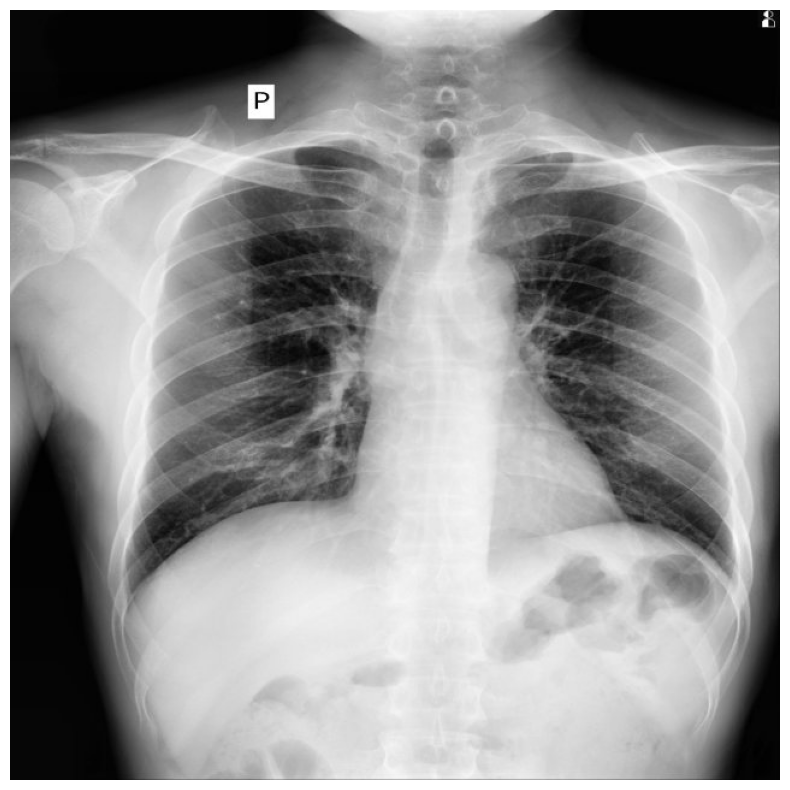

In [13]:
sample_row = val_split.iloc[0]
sample_id = sample_row["image_id"]
sample_path = get_cache_path(sample_id)

print("Sample:", sample_id)
res = hybrid_predict(sample_path, conf640=0.10, conf1024=0.08, max_refine_boxes=12)
print(res["message"])
print("Binary prob:", res["binary_prob"])
print("Detections:", len(res["detections"]))

img_vis = res["raw"].copy()
if len(res["detections"]) > 0:
    img_vis = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
    for d in res["detections"]:
        x1, y1, x2, y2 = map(int, d["bbox"])
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_vis, f'{d["class_name"]} {d["conf"]:.2f}', (x1, max(0, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
else:
    img_vis = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()